In [18]:
import numpy as np
from numpy.linalg import eigh
from functools import partial
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
# 方法一：使用系统自带的中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [ ]:
def build_H(EC, EJ_list, ng, n_cut):
    n = np.arange(-n_cut, n_cut+1)
    dim = len(n)
    H = np.zeros((dim, dim), dtype=float)

    # Charging energy
    H += np.diag(4 * EC * (n - ng)**2)

    # Josephson harmonics: EJ_list[m-1] = EJ_m
    for m, EJm in enumerate(EJ_list, start=1):
        off = np.full(dim-m, -EJm/2.0)
        H += np.diag(off,  k= m)
        H += np.diag(off,  k=-m)

    return H

def levels_from_params(params, ng, n_cut, n_level=5):
    EC = params[0]
    EJ_list = params[1:]  # [EJ1, EJ2, ...]
    H = build_H(EC, EJ_list, ng, n_cut)
    evals, _ = eigh(H)
    evals = np.sort(evals)[:n_level]
    return evals

def residual(params, data, n_cut):
    # data: dict with keys like ('ng', 'transitions'): list of points
    res = []
    for d in data:
        ng = d['ng']
        target = np.array(d['w01_w12_w23_w34'])
        evals = levels_from_params(params, ng, n_cut, n_level=5)
        theo = np.array([
            evals[1]-evals[0],
            evals[2]-evals[1],
            evals[3]-evals[2],
            evals[4]-evals[3],
        ])
        res.extend(theo - target)
    # 可以在这里加入对 EJm 符号/单调性的正则化惩罚项
    return np.array(res)

# 使用举例：
# params = [EC_init, EJ1_init, EJ2_init]   # 推荐先只到 EJ2
# result = least_squares(residual, params, args=(data, n_cut))
# 拿到 result.x 即为拟合得到的 EC, EJ1, EJ2


In [15]:
n_cut = 30
ng = 0.5
EC = 1.0  # GHz

n = np.arange(-n_cut, n_cut + 1)
dim = len(n)
H = np.zeros((dim, dim))

# 充电能项
H += np.diag(4 * EC * (n - ng)**2)

print(np.shape(H))
print(H)
EJ = 15.0  # GHz
off_diag = -EJ / 2.0 * np.ones(dim - 1)
V = np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
print(V)

(61, 61)
[[3721.    0.    0. ...    0.    0.    0.]
 [   0. 3481.    0. ...    0.    0.    0.]
 [   0.    0. 3249. ...    0.    0.    0.]
 ...
 [   0.    0.    0. ... 3025.    0.    0.]
 [   0.    0.    0. ...    0. 3249.    0.]
 [   0.    0.    0. ...    0.    0. 3481.]]
[[ 0.  -7.5  0.  ...  0.   0.   0. ]
 [-7.5  0.  -7.5 ...  0.   0.   0. ]
 [ 0.  -7.5  0.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ...  0.  -7.5  0. ]
 [ 0.   0.   0.  ... -7.5  0.  -7.5]
 [ 0.   0.   0.  ...  0.  -7.5  0. ]]


# Plot transmon's charge dispersion

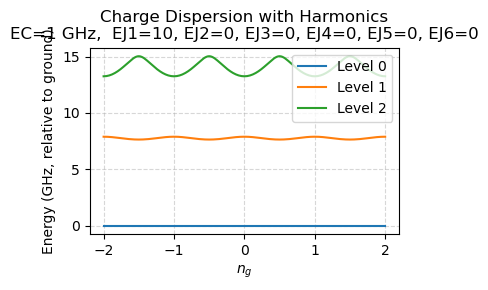

In [3]:
def hamiltonian_with_harmonics(EC, EJ_list, ng, n_cut):
    """
    构造含多阶 Josephson 谐波的哈密顿量:
        H = 4EC (n - ng)^2 - Σ_m EJ_m cos(mφ)
    
    参数:
        EC : float
            充电能 (GHz)
        EJ_list : list[float]
            [EJ1, EJ2, EJ3, ... EJm] 各阶 Josephson 谐波系数
        ng : float
            偏置电荷 (0 ~ 1)
        n_cut : int
            charge 截断 (总维度 = 2*n_cut + 1)
    """
    n = np.arange(-n_cut, n_cut + 1)
    dim = len(n)
    H = np.diag(4 * EC * (n - ng)**2)  # Charging term

    # 加入各阶 Josephson 谐波
    for m, EJm in enumerate(EJ_list, start=1):
        off_diag = -EJm / 2.0 * np.ones(dim - m)
        H += np.diag(off_diag, k=m) + np.diag(off_diag, k=-m)
    
    return H


def compute_spectrum(EC, EJ_list, ng_range=(0, 1), ng_points=101, n_cut=30, n_levels=5):
    """
    扫描 ng 并计算前 n_levels 个能级
    
    参数:
        EC : float
        EJ_list : list[float]
        ng_range : tuple(float, float)
            ng 扫描范围 (start, end)
        ng_points : int
            ng 采样点数量
        n_cut : int
            charge 截断
        n_levels : int
            计算能级数
    返回:
        ng_list, energies  (shape: [n_levels, ng_points])
    """
    ng_list = np.linspace(ng_range[0], ng_range[1], ng_points)
    energies = np.zeros((n_levels, ng_points))

    for i, ng in enumerate(ng_list):
        H = hamiltonian_with_harmonics(EC, EJ_list, ng, n_cut)
        evals, _ = eigh(H)
        evals = np.sort(evals)
        energies[:, i] = evals[:n_levels] - evals[0]
    
    return ng_list, energies


def plot_charge_dispersion(EC, EJ_list, ng_range=(0, 1), ng_points=101,
                           n_cut=30, n_levels=5, figsize=(8, 5)):
    """
    绘制多谐波 Transmon 的电荷色散图
    
    参数:
        EC : float
            充电能 (GHz)
        EJ_list : list[float]
            Josephson 谐波系数列表 [EJ1, EJ2, EJ3, ...]
        ng_range : tuple(float, float)
            ng 范围，例如 (0, 1)
        ng_points : int
            ng 扫描点数
        n_cut : int
            charge 截断
        n_levels : int
            要绘制的能级数
        figsize : tuple(float, float)
            图像尺寸
    """
    ng_list, energies = compute_spectrum(EC, EJ_list, ng_range, ng_points, n_cut, n_levels)
    
    plt.figure(figsize=figsize)
    for i in range(energies.shape[0]):
        plt.plot(ng_list, energies[i], label=f"Level {i}")
    
    ej_desc = ", ".join([f"EJ{m+1}={EJ:.3g}" for m, EJ in enumerate(EJ_list)])
    plt.title(f"Charge Dispersion with Harmonics\nEC={EC:.3g} GHz,  {ej_desc}")
    plt.xlabel("$n_g$")
    plt.ylabel("Energy (GHz, relative to ground)")
    plt.grid(True, ls="--", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

EC = 1  # GHz
# EJ_list = [15.0, -0.3, 0.1, -0.05, 0.02, -0.01]  # EJ1~EJ6
EJ_list = [10, 0, 0, 0, 0, 0]  # EJ1~EJ6
plot_charge_dispersion(
    EC=EC,
    EJ_list=EJ_list,
    ng_range=(-2, 2),   # 可自由调整范围，如 (0, 1)
    ng_points=201,
    n_cut=40,
    n_levels=3,
    figsize=(4, 3)
)

In [7]:
# -------------------------------------------------------------------
# 1. 计算 EC, EJ
# -------------------------------------------------------------------
def extract_EC_EJ(f01_exp, f12_exp):
    """
    根据实验 f01, f12 提取 EC, EJ  (GHz)
    """
    EC = f01_exp - f12_exp  # charging energy
    EJ = ( (f01_exp + EC)**2 ) / (8 * EC)
    return EC, EJ


# -------------------------------------------------------------------
# 2. 构造标准 Transmon 哈密顿量
# -------------------------------------------------------------------
def transmon_H(EC, EJ, n_cut=40):
    """
    返回标准 transmon 哈密顿量矩阵
    H = 4EC n^2 - EJ cos(phi)
    """
    n = np.arange(-n_cut, n_cut + 1)
    dim = len(n)
    H = np.diag(4 * EC * n**2)
    off_diag = -EJ / 2.0 * np.ones(dim - 1)
    H += np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    return H


# -------------------------------------------------------------------
# 3. 计算前 N 个能级
# -------------------------------------------------------------------
def get_transmon_levels(EC, EJ, n_cut=40, n_levels=6):
    H = transmon_H(EC, EJ, n_cut)
    evals, _ = eigh(H)
    evals = np.sort(evals)[:n_levels]
    return evals


# -------------------------------------------------------------------
# 4. 主函数：从实验数据 → 理论能级 → 绘图
# -------------------------------------------------------------------
def analyze_transmon_from_data(f01, f12, f23, f34, f45, n_cut=40, figsize=(6,4)):
    """
    输入实验频率 (GHz)，计算 EJ, EC，并比较理论与实验能级差。
    """
    # === Step 1. 提取 EJ, EC ===
    EC, EJ = extract_EC_EJ(f01, f12)
    print(f"Extracted parameters:")
    print(f"  EC = {EC:.4f} GHz")
    print(f"  EJ = {EJ:.4f} GHz")
    print(f"  EJ/EC = {EJ/EC:.1f}")

    # === Step 2. 理论能级 ===
    E_th = get_transmon_levels(EC, EJ, n_cut, n_levels=6)
    f_th = E_th - E_th[0]  # 相对基态能量
    f_th_01to5 = f_th[1:]  # f01, f02, ... f05

    # === Step 3. 实验能级 (累加获得 0→j 频率) ===
    f_exp_transitions = np.array([f01, f12, f23, f34, f45])
    f_exp_01to5 = np.cumsum(f_exp_transitions)

    # === Step 4. 差值 ===
    diff = f_th_01to5 - f_exp_01to5

    # === Step 5. 绘图 ===
    labels = [f"0–{j}" for j in range(1, 6)]
    plt.figure(figsize=figsize)
    plt.plot(labels, diff, "o-", lw=2)
    plt.axhline(0, color="gray", ls="--", alpha=0.7)
    plt.title("Transmon Transition Frequency Difference\n(experimental − theoretical)")
    plt.xlabel("Transition")
    plt.ylabel("Δf (GHz)")
    plt.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

    return EC, EJ, E_th, diff


Extracted parameters:
  EC = 0.1700 GHz
  EJ = 16.1047 GHz
  EJ/EC = 94.7


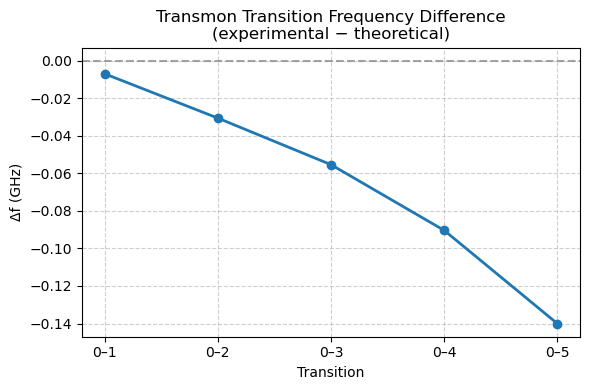

(0.16999999999999993,
 16.104705882352945,
 array([-13.80802361,  -9.30488016,  -4.98851386,  -0.87333542,
          3.02163301,   6.67193882]),
 array([-0.00685655, -0.03049025, -0.05531181, -0.09034338, -0.14003757]))

In [8]:
# 实验数据 (GHz)
f01, f12, f23, f34, f45 = 4.51, 4.34, 4.14, 3.93, 3.70
analyze_transmon_from_data(f01, f12, f23, f34, f45)


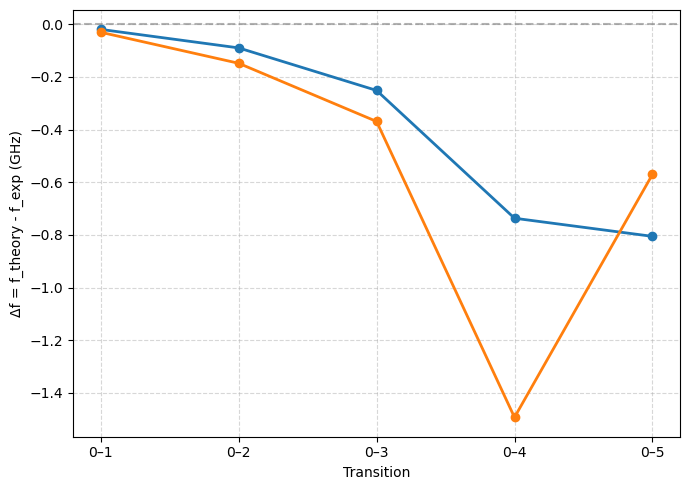

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh


# -------------------------------------------------------------------
# 计算 EC, EJ
# -------------------------------------------------------------------
def extract_EC_EJ(f_exp):
    """
    从实验 f01, f12 提取 EC, EJ  (GHz)
    f_exp: array([f01, f12, ...])
    """
    f01, f12 = f_exp[0], f_exp[1]
    EC = f01 - f12
    EJ = ((f01 + EC) ** 2) / (8 * EC)
    return EC, EJ


# -------------------------------------------------------------------
# Transmon 哈密顿量
# -------------------------------------------------------------------
def transmon_H(EC, EJ, n_cut=40):
    n = np.arange(-n_cut, n_cut + 1)
    dim = len(n)
    H = np.diag(4 * EC * n**2)
    off_diag = -EJ / 2.0 * np.ones(dim - 1)
    H += np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
    return H


# -------------------------------------------------------------------
# 求能级
# -------------------------------------------------------------------
def get_transmon_levels(EC, EJ, n_cut=40, n_levels=6):
    H = transmon_H(EC, EJ, n_cut)
    evals, _ = eigh(H)
    return np.sort(evals)[:n_levels]


# -------------------------------------------------------------------
# 分析单个实验数据集
# -------------------------------------------------------------------
def analyze_one_dataset(f_exp, n_cut=40):
    """
    输入：f_exp = np.array([f01, f12, f23, f34, f45])
    返回：(EC, EJ, E_theory, f_diff)
    """
    EC, EJ = extract_EC_EJ(f_exp)
    E_th = get_transmon_levels(EC, EJ, n_cut, n_levels=6)
    f_th = E_th - E_th[0]
    f_th_01to5 = f_th[1:]

    f_exp_01to5 = np.cumsum(f_exp)  # 累积得到 0→j 跃迁
    diff = f_th_01to5 - f_exp_01to5
    return EC, EJ, E_th, diff


# -------------------------------------------------------------------
# 主函数：多组实验数据对比绘图
# -------------------------------------------------------------------
def plot_multiple_transmon_datasets(f_exp_list, labels=None, n_cut=40, figsize=(7, 5), title=""):
    """
    f_exp_list: list[np.array]，每个为一组实验跃迁频率 [f01, f12, f23, f34, f45]
    labels: 每组数据的标签
    """
    n_sets = len(f_exp_list)
    if labels is None:
        labels = [f"dataset {i+1}" for i in range(n_sets)]

    plt.figure(figsize=figsize)
    transitions = [f"0–{j}" for j in range(1, 6)]

    for f_exp, label in zip(f_exp_list, labels):
        
        EC, EJ, E_th, diff = analyze_one_dataset(f_exp, n_cut)
        # print(f"\n[{label}]  EC={EC:.4f} GHz, EJ={EJ:.4f} GHz, EJ/EC={EJ/EC:.1f}")
        plt.plot(transitions, diff, "o-", lw=2, label=f"{label} (EJ/EC={EJ/EC:.1f})")

    plt.axhline(0, color="gray", ls="--", alpha=0.6)
    plt.xlabel("Transition")
    plt.ylabel("Δf = f_theory - f_exp (GHz)")
    plt.title(title)
    plt.grid(True, ls="--", alpha=0.5)
    # plt.legend()
    plt.tight_layout()
    plt.show()


# -------------------------------------------------------------------
# 示例运行
# -------------------------------------------------------------------
if __name__ == "__main__":
    # 两组假数据（GHz）
    f_exp1 = np.array([5.2, 4.9, 4.6, 4.3, 4.0])  # 较弱非线性
    f_exp2 = np.array([6.0, 5.6, 5.2, 4.8, 4.4])  # 较强非线性

    plot_multiple_transmon_datasets(
        f_exp_list=[f_exp1, f_exp2],
        labels=["sample A", "sample B"],
        n_cut=40,
        figsize=(7, 5),
    )


In [2]:
import pandas as pd

file_path = "frequency_10.xlsx"   # 修改为你的文件路径
df_10 = pd.read_excel(file_path, sheet_name=0)  # sheet_name 可以是名称或索引号

# 打印前几行数据
print(df_10.head())

   Unnamed: 0           f01           f12           f23           f34  \
0           0  4.513021e+09  4.336005e+09  4.140550e+09  3.926954e+09   
1           2  4.731272e+09  4.552771e+09  4.358582e+09  4.146181e+09   
2          28  4.556245e+09  4.384723e+09  4.197318e+09  3.991738e+09   
3          36  4.547903e+09  4.368634e+09  4.173594e+09  3.958698e+09   
4          48  4.473590e+09  4.300060e+09  4.112235e+09  3.903339e+09   

            f45  
0  3.702583e+09  
1  3.911042e+09  
2  3.774418e+09  
3  3.717812e+09  
4  3.672718e+09  


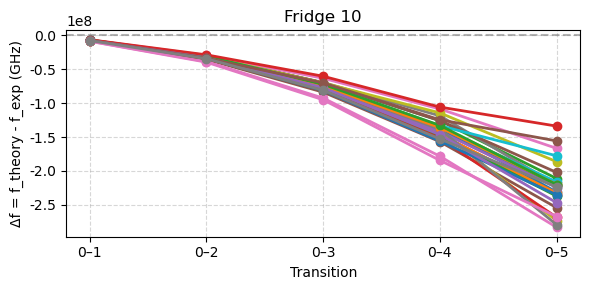

In [21]:

plot_multiple_transmon_datasets(
    f_exp_list=df_10.iloc[:, 1:].to_numpy(),
    labels=df_10.iloc[:, 0],
    n_cut=40,
    figsize=(6, 3),
    title="Fridge 10"
)